# EDA — Phase 4
Work on train.parquet only. Never touch test.parquet.

In [1]:
# CELL 1 — Load and overview
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROJ = '/home/tayana-gpu/ML/project_01_product_classifier'
os.makedirs(f'{PROJ}/figures', exist_ok=True)

df = pd.read_parquet(f'{PROJ}/data/train.parquet')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nNull counts:')
print(df.isnull().sum())
print(f'\nSample rows:')
print(df[['unspsc_segment','text']].sample(3, random_state=1).to_string())

Shape: (72940, 3)
Columns: ['text', 'unspsc_segment', 'label']

Null counts:
text              0
unspsc_segment    0
label             0
dtype: int64

Sample rows:
                                                          unspsc_segment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

                                                                   count   pct
unspsc_segment                                                                
Apparel and Luggage and Personal Care Products                     29450  40.4
Domestic Appliances and Supplies and Consumer Electronic Products  11277  15.5
Electronic Components and Supplies                                  7574  10.4
Building and Construction Machinery and Accessories                 6319   8.7
Transportation and Storage and Mail Services                        4769   6.5
Office Equipment and Accessories and Supplies                       3150   4.3
Pharmaceuticals and Healthcare Products                             2769   3.8
Sports and Recreational Equipment and Supplies                      2576   3.5
Industrial Machinery and Equipment                                  1955   2.7
Animals and Birds and Fish                                          1499   2.1
Audio and Visual Presentation and Composing Equipmen

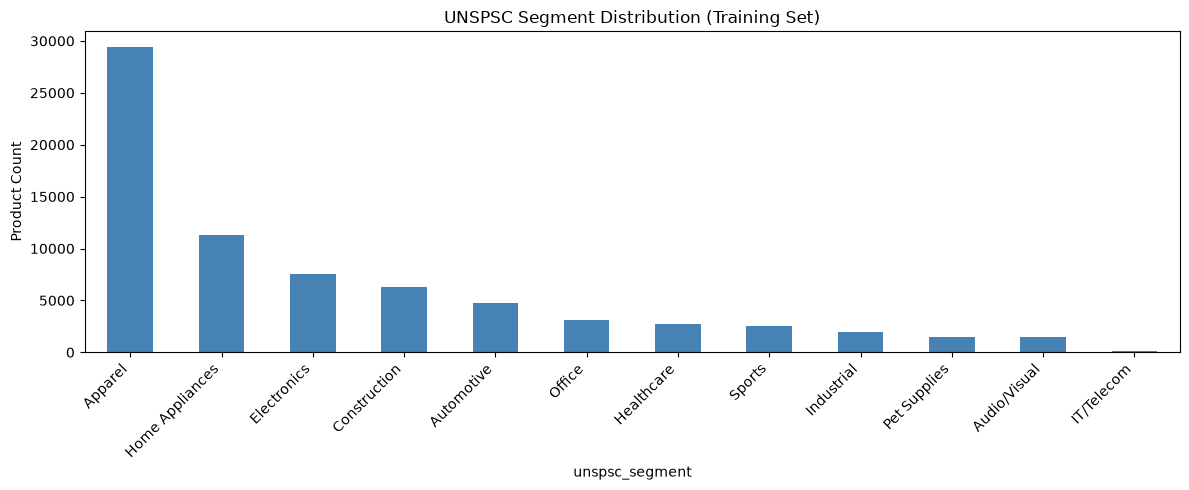

Saved figures/category_distribution.png


In [2]:
# CELL 2 — Class distribution chart
counts = df['unspsc_segment'].value_counts()
pct = (counts / len(df) * 100).round(1)
dist = pd.DataFrame({'count': counts, 'pct': pct})
print(dist.to_string())
print(f'\nImbalance ratio: {counts.max()/counts.min():.1f}x')

# Short labels for plot
SHORT = {
    'Apparel and Luggage and Personal Care Products': 'Apparel',
    'Domestic Appliances and Supplies and Consumer Electronic Products': 'Home Appliances',
    'Electronic Components and Supplies': 'Electronics',
    'Building and Construction Machinery and Accessories': 'Construction',
    'Transportation and Storage and Mail Services': 'Automotive',
    'Office Equipment and Accessories and Supplies': 'Office',
    'Pharmaceuticals and Healthcare Products': 'Healthcare',
    'Sports and Recreational Equipment and Supplies': 'Sports',
    'Industrial Machinery and Equipment': 'Industrial',
    'Animals and Birds and Fish': 'Pet Supplies',
    'Audio and Visual Presentation and Composing Equipment': 'Audio/Visual',
    'Information Technology Broadcasting and Telecommunications': 'IT/Telecom',
}
plot_counts = counts.rename(SHORT)

plt.figure(figsize=(12, 5))
plot_counts.plot(kind='bar', color='steelblue')
plt.title('UNSPSC Segment Distribution (Training Set)')
plt.ylabel('Product Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJ}/figures/category_distribution.png', dpi=150)
plt.show()
print('Saved figures/category_distribution.png')

=== Text Length Stats ===
       word_count  char_count
count     72940.0     72940.0
mean        124.6       760.0
std          95.7       575.3
min           3.0        12.0
10%          29.0       185.0
25%          50.0       308.0
50%          99.0       610.0
75%         179.0      1107.0
90%         259.0      1567.0
max        2685.0     17093.0

% with < 5 words:  0.1%
% with < 10 words: 0.6%
% with < 20 words: 3.9%

Median word count per segment:
unspsc_segment
Apparel             80.0
Sports              83.0
Automotive          99.0
Audio/Visual       102.0
Industrial         102.0
Healthcare         103.0
Construction       112.0
Office             120.5
Home Appliances    123.0
Pet Supplies       123.0
Electronics        131.5
IT/Telecom         202.0


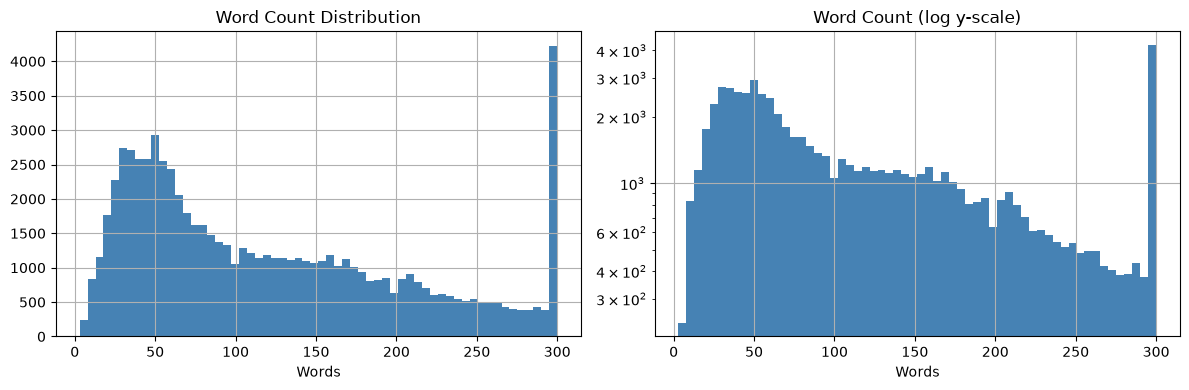

Saved figures/text_length_distribution.png


In [3]:
# CELL 3 — Text length distribution
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

print('=== Text Length Stats ===')
print(df[['word_count','char_count']].describe(percentiles=[.1,.25,.5,.75,.9]).round(1))

print(f'\n% with < 5 words:  {(df["word_count"] < 5).mean()*100:.1f}%')
print(f'% with < 10 words: {(df["word_count"] < 10).mean()*100:.1f}%')
print(f'% with < 20 words: {(df["word_count"] < 20).mean()*100:.1f}%')

print('\nMedian word count per segment:')
print(df.groupby('unspsc_segment')['word_count'].median().rename(SHORT).sort_values().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['word_count'].clip(upper=300).hist(bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Words')
df['word_count'].clip(upper=300).hist(bins=60, ax=axes[1], color='steelblue', log=True)
axes[1].set_title('Word Count (log y-scale)')
axes[1].set_xlabel('Words')
plt.tight_layout()
plt.savefig(f'{PROJ}/figures/text_length_distribution.png', dpi=150)
plt.show()
print('Saved figures/text_length_distribution.png')

In [4]:
# CELL 4 — Vocabulary analysis
from collections import Counter

all_words = ' '.join(df['text'].tolist()).split()
word_freq = Counter(all_words)

print(f'Total vocabulary size: {len(word_freq):,}')
print(f'Words appearing only once: {sum(1 for _,c in word_freq.items() if c==1):,}')
print(f'\nTop 30 most frequent words:')
print([w for w,_ in word_freq.most_common(30)])

print('\nTop 10 words per segment:')
for seg in df['unspsc_segment'].unique():
    seg_words = Counter(' '.join(df[df['unspsc_segment']==seg]['text']).split())
    short_name = SHORT.get(seg, seg[:20])
    print(f'  {short_name}: {[w for w,_ in seg_words.most_common(10)]}')

Total vocabulary size: 245,727
Words appearing only once: 133,545

Top 30 most frequent words:
['and', 'the', 'for', 'to', 'a', 'with', 'of', 'your', 'is', 'you', 'in', 's', 'or', 'it', '-', 'women', 'are', 'x', 'this', 'can', 'on', 'size', 'our', 'that', '1', 'from', 'be', 'will', 'as', 'not']

Top 10 words per segment:
  Construction: ['the', 'and', 'for', 'to', 'with', 'a', 'of', 'your', 'is', 'you']
  Electronics: ['the', 'and', 'for', 'to', 'with', 'a', 'your', 'case', 'you', 'of']
  Apparel: ['and', 'the', 'for', 'to', 'a', 'with', 'of', 'women', 's', 'you']
  Home Appliances: ['and', 'the', 'for', 'to', 'a', 'with', 'of', 'your', 'is', 'you']
  Automotive: ['the', 'and', 'for', 'to', 'with', 'car', 'your', 'of', 'a', 'is']
  Sports: ['the', 'and', 'for', 'to', 'a', 'with', 'of', 'your', 'you', 'is']
  Pet Supplies: ['and', 'the', 'for', 'to', 'dog', 'your', 'a', 'with', 'of', 'is']
  Industrial: ['and', 'the', 'for', 'to', 'with', 'of', 'a', 'is', 'your', 'in']
  Audio/Visual: [

In [ ]:
# CELL 5 — Product code / abbreviation detection
import re

code_pat = re.compile(r'\b[A-Z]{2,}[0-9]*\b|\b[A-Z][0-9]{2,}\b')
df['has_code'] = df['text'].apply(lambda x: bool(code_pat.search(x)))
print(f'% of products with product codes/abbreviations: {df["has_code"].mean()*100:.1f}%')

print('\nPer segment:')
print(df.groupby('unspsc_segment')['has_code'].mean().rename(SHORT).sort_values(ascending=False).round(3).to_string())

sample_codes = []
for text in df['text'].sample(1000, random_state=42):
    sample_codes.extend(code_pat.findall(text.upper()))
print(f'\nTop 20 codes found in sample:')
print(Counter(sample_codes).most_common(20))

% of products with product codes/abbreviations: 100.0%

Per segment:
unspsc_segment
Pet Supplies       1.0
Apparel            1.0
Audio/Visual       1.0
Construction       1.0
Home Appliances    1.0
Electronics        1.0
Industrial         1.0
IT/Telecom         1.0
Office             1.0
Healthcare         1.0
Sports             1.0
Automotive         1.0

Top 20 codes found in sample:
[('AND', 3486), ('THE', 3420), ('FOR', 2630), ('TO', 2239), ('WITH', 1630), ('OF', 1420), ('IS', 1109), ('YOU', 1094), ('YOUR', 1082), ('IN', 959), ('WOMEN', 751), ('IT', 701), ('OR', 589), ('CAN', 579), ('THIS', 575), ('ARE', 564), ('ON', 537), ('SIZE', 521), ('OUR', 440), ('BE', 413)]


In [6]:
# CELL 6 — Label noise check
label_noise = df.groupby('text')['unspsc_segment'].nunique()
noisy = label_noise[label_noise > 1]
print(f'Texts with conflicting labels: {len(noisy):,} ({len(noisy)/len(df)*100:.2f}%)')

non_ascii = df['text'].apply(lambda x: sum(1 for c in x if ord(c) > 127) / max(len(x),1))
print(f'\n% with any non-ASCII: {(non_ascii > 0).mean()*100:.1f}%')
print(f'% with > 10% non-ASCII: {(non_ascii > 0.1).mean()*100:.1f}%')

Texts with conflicting labels: 0 (0.00%)

% with any non-ASCII: 0.0%
% with > 10% non-ASCII: 0.0%


In [7]:
# CELL 7 — EDA Summary Table
counts = df['unspsc_segment'].value_counts()
findings = {
    'Total training rows':                       f'{len(df):,}',
    'Number of UNSPSC segments':                  str(df["unspsc_segment"].nunique()),
    'Imbalance ratio (max/min)':                 f'{counts.max()/counts.min():.0f}x',
    '% products with < 10 words':                f'{(df["word_count"] < 10).mean()*100:.1f}%',
    'Median word count':                          str(int(df["word_count"].median())),
    '% with product codes/abbreviations':         f'{df["has_code"].mean()*100:.1f}%',
    'Total vocabulary size':                      f'{len(word_freq):,}',
    '% label noise (same text, diff label)':      f'{len(noisy)/len(df)*100:.2f}%',
    '% non-ASCII content (> 10%)':               f'{(non_ascii > 0.1).mean()*100:.1f}%',
}

print('=== EDA SUMMARY TABLE ===')
for k, v in findings.items():
    print(f'  {k:<45} {v}')

print('\nModeling decisions:')
if counts.max()/counts.min() > 5:
    print('  [YES] Use class_weight="balanced" in LinearSVC')
if (df['word_count'] < 10).mean() > 0.2:
    print('  [YES] char n-grams essential (> 20% short texts)')
if df['has_code'].mean() > 0.3:
    print('  [YES] FastText subword essential (> 30% have product codes)')

=== EDA SUMMARY TABLE ===
  Total training rows                           72,940
  Number of UNSPSC segments                     12
  Imbalance ratio (max/min)                     239x
  % products with < 10 words                    0.6%
  Median word count                             99
  % with product codes/abbreviations            100.0%
  Total vocabulary size                         245,727
  % label noise (same text, diff label)         0.00%
  % non-ASCII content (> 10%)                   0.0%

Modeling decisions:
  [YES] Use class_weight="balanced" in LinearSVC
  [YES] FastText subword essential (> 30% have product codes)
